In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import sctk as sk
import matplotlib.pyplot as plt
import os
import sys
import scipy
import matplotlib
from matplotlib import rcParams
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all" # to show output from all the lines in a cells
pd.set_option('display.max_column',None) # display all the columns in pandas
pd.options.display.max_rows = 100
rcParams['pdf.fonttype'] = 42
sc.settings.figdir = './figures/SGN_analysis/'
sc.settings.set_figure_params(dpi = 150, color_map = 'RdPu', dpi_save = 600, vector_friendly = True, format = 'pdf')

In [2]:
cd F:\PROJECTS\PROJECT_HUMAN_FETAL_COCHLEAE\WORKPLACE\R\sc_pipeline\

F:\PROJECTS\PROJECT_HUMAN_FETAL_COCHLEAE\WORKPLACE\R\sc_pipeline


In [3]:
data_dir = '/PROJECTS/PROJECT_HUMAN_FETAL_COCHLEAE/WORKPLACE/R/sc_pipeline/'
meta = pd.read_csv(data_dir+'metadata.csv',index_col=0)
meta

,sample_id,donor,gw,gender,10xKit,sequencing,dataset,species
sample,,,,,,,,
9.5gw,gw9,not_provided_1,9.0,female,SC3,snRNA-seq,public,Homo sapiens
11.2gw,gw11,not_provided_2,11.0,male,SC3,snRNA-seq,public,Homo sapiens
14+3gw,gw14,F20240701,14.0,male,SC3,snRNA-seq,in-house,Homo sapiens
15gw,gw15,not_provided_3,15.0,female,SC3,scRNA-seq,public,Homo sapiens
16+4gw,gw16,F20241018,16.0,male,SC3,snRNA-seq,in-house,Homo sapiens
17+2gw,gw17_1,F20220807,17.0,male,SC3,snRNA-seq,in-house,Homo sapiens
17+3gw,gw17_2,F20240928,17.0,female,SC3,snRNA-seq,in-house,Homo sapiens
17gw,gw17_3,not_provided_4,17.0,male,SC3,scRNA-seq,public,Homo sapiens
18+3gw,gw18,F20220806,18.0,male,SC3,snRNA-seq,in-house,Homo sapiens


In [4]:
adata_sgn=sc.read("human_sgn_scANVI_integration.h5ad")
adata_sgn
adata_sgn.obs['cell_type_final'].value_counts()

AnnData object with n_obs × n_vars = 806 × 24804
    obs: 'batch', 'CellID', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'louvain', 'leiden_R', 'cell_type', 'doublet_score', 'predicted_doublet', 'leiden_0.8', 'leiden_0.4', 'cell_type_final', 'scVI_res_1', 'scANVI_res2.0', 'scANVI_res0.8', 'scANVI_res1.0'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'batch_colors', 'cell_type_final_colors', 'hvg', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'scANVI_res0.8', 'scANVI_res0.8_colors', 'scANVI_res1.0', 'scANVI_res1.0_colors', 'scANVI_res2.0', 'scANVI_res2.0_colors', 'scVI_res_1', 'scVI_res_1_colors', 'umap'
    obsm: 'X_harmony', 'X_pca', 'X_scANVI', 'X_scVI', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

cell_type_final
LYPD1+_immature_sgn         207
CLU+_mature_sgn             122
RUNX1+_mature_sgn           121
IGFBP2+_intermediate_sgn    111
NEUROD1+_early_sgn           93
ALDH1A3+_immature_sgn        85
PRPH+_immature_sgn           67
Name: count, dtype: int64

In [5]:
adata=sc.read('human_cochlea_annotation.h5ad')
adata

AnnData object with n_obs × n_vars = 82533 × 13994
    obs: 'batch', 'CellID', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'louvain', 'cell_type', 'n_genes', 'sample', 'sample_id', 'donor', 'gw', 'gender', '10xKit', 'sequencing', 'dataset', 'percent_mito', 'n_counts', 'nCount_RNA', 'nFeature_RNA', 'leiden_R', 'low_ncounts', 'high_mito', 'low_ncounts_high_mito', 'S_score', 'G2M_score', 'phase', 'scrublet_score', 'scrublet_cluster_score', 'zscore', 'bh_pval', 'bonf_pval', 'is_doublet', 'leiden_res1.0', 'is_doublet_scrub', 'leiden_res1.1', 'leiden_res4.0', 'leiden_res2.0', '_scvi_batch', '_scvi_labels', 'leiden_scanvi_2.0', 'leiden_scanvi_3.0', 'leiden_scanvi_4.0', 'cell_type_final'
    var: 'Gene', 'mt', 'gene_ids-0', 'feature_types-0', 'n_cells_by_counts-0', 'mean_counts-0', 'pct_dropout_by_counts-0', 'total_counts-0', 'highly_variable-0', 'means-0', 'dispersions-0', 'dispersions_norm-0', 'n_cells-0', 'gene_ids-1', 'feature_types-1', 'n_cells_by_co

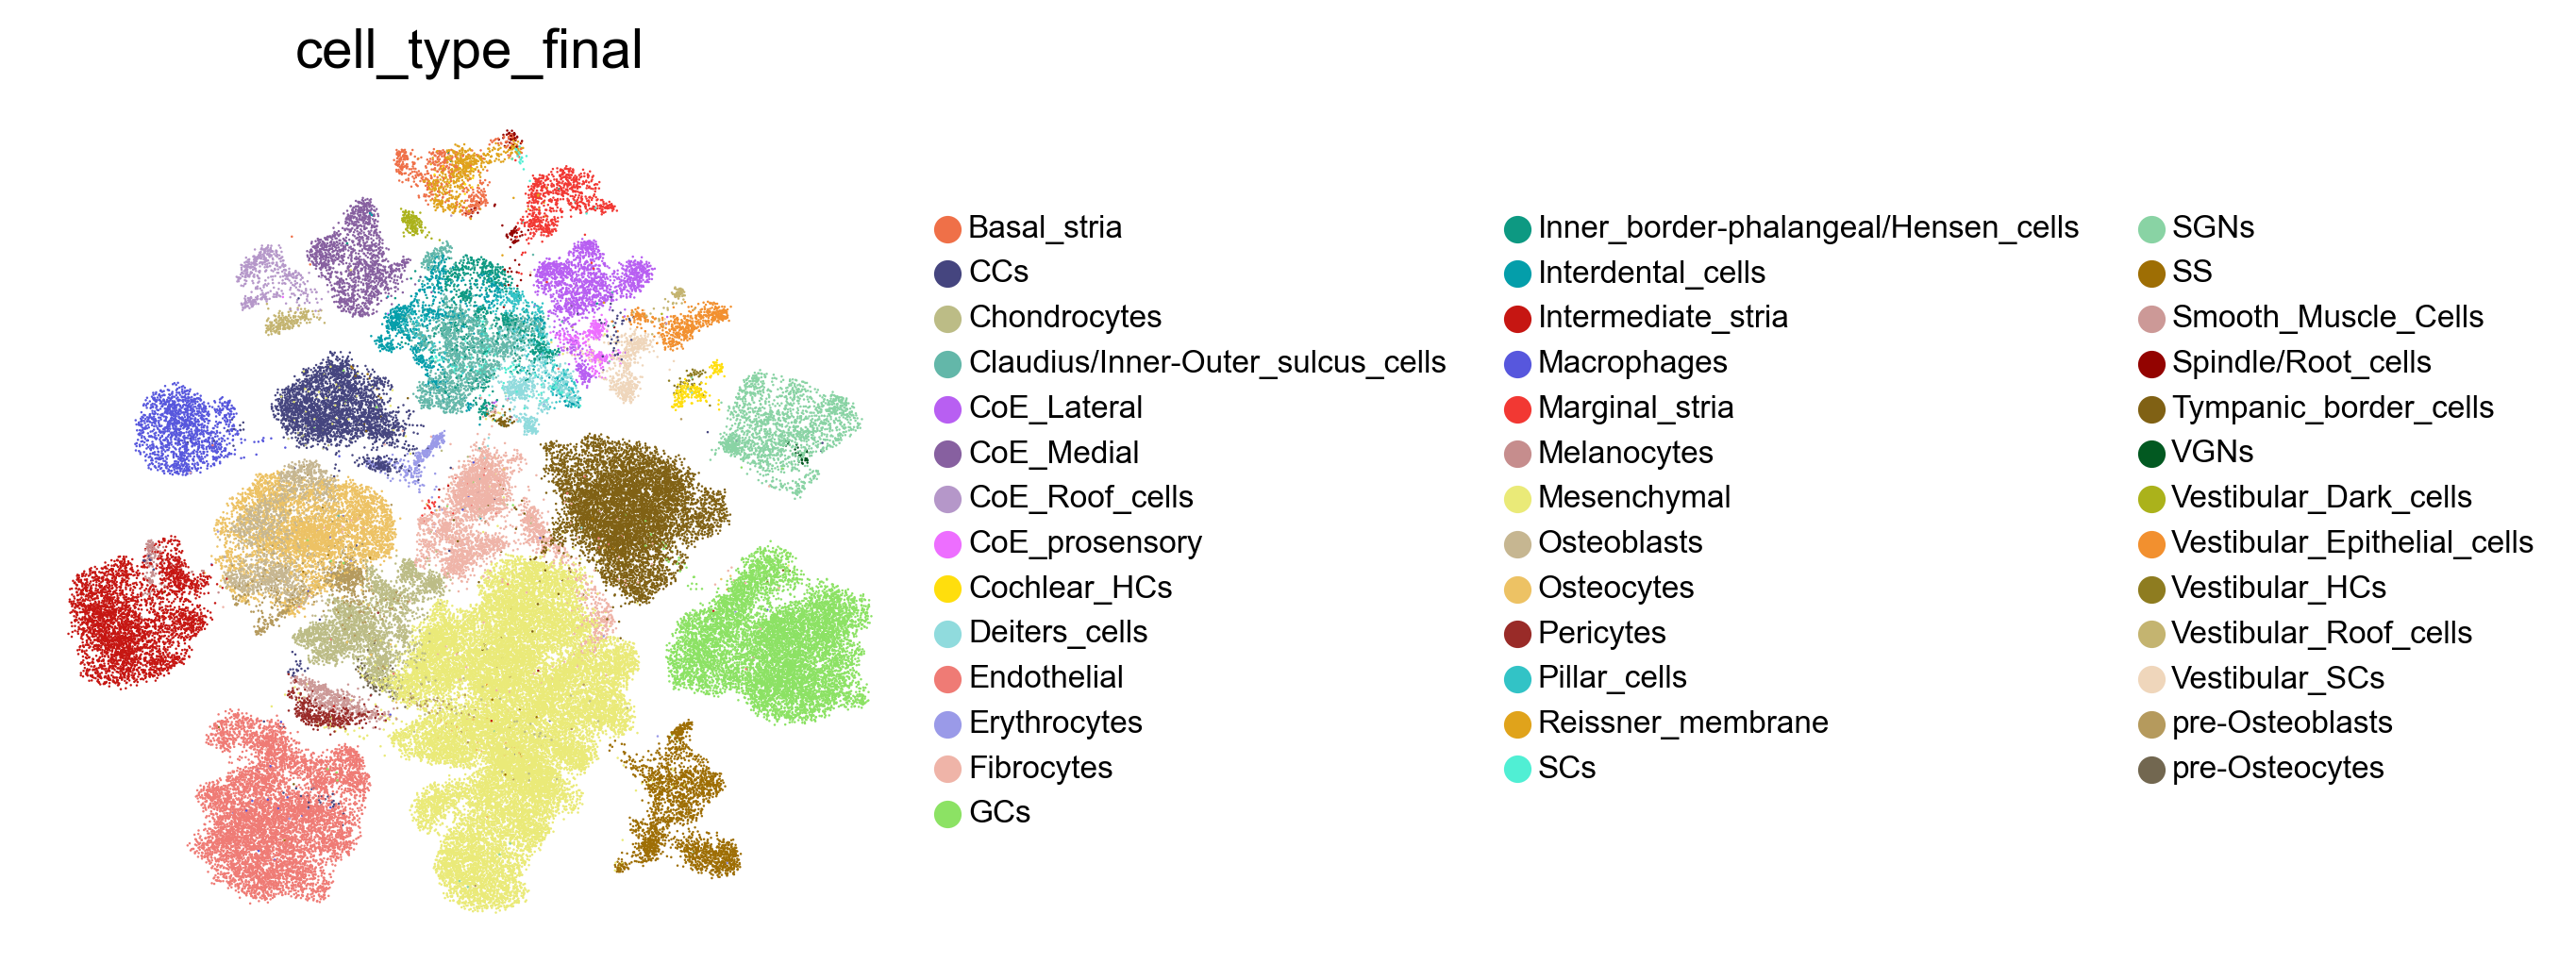

In [6]:
sc.set_figure_params(figsize=(4,4),frameon=False,dpi=150,dpi_save=600)
sc.pl.umap(
    adata,legend_fontsize=8,
    color="cell_type_final",)

In [7]:
adata.obs["sel1"]=(adata.obs.cell_type_final=='SGNs').astype(str)

In [9]:
import scvelo as scv

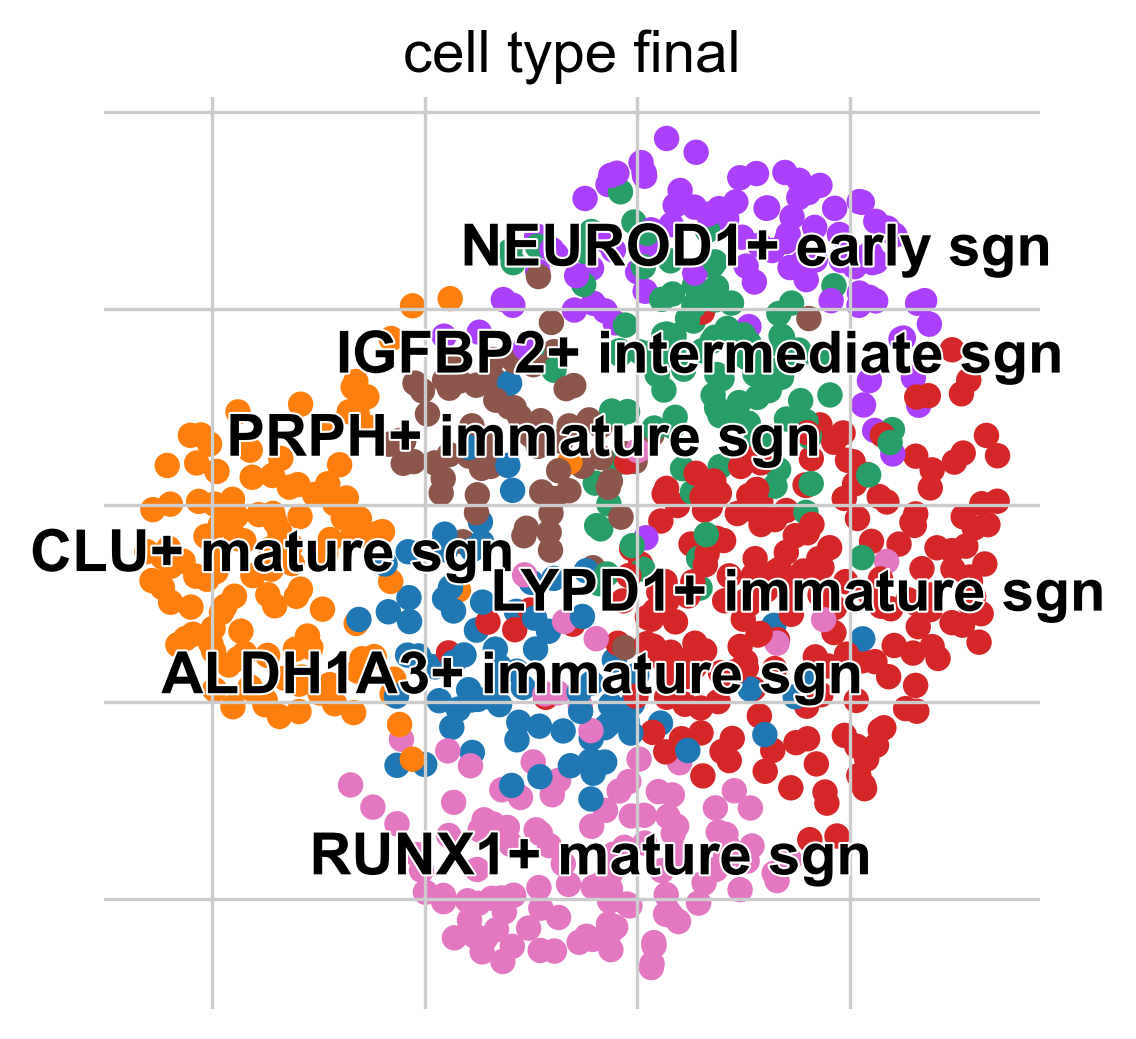

saving figure to file ./figures/SGN_analysis/human_sgn_highlight.pdf


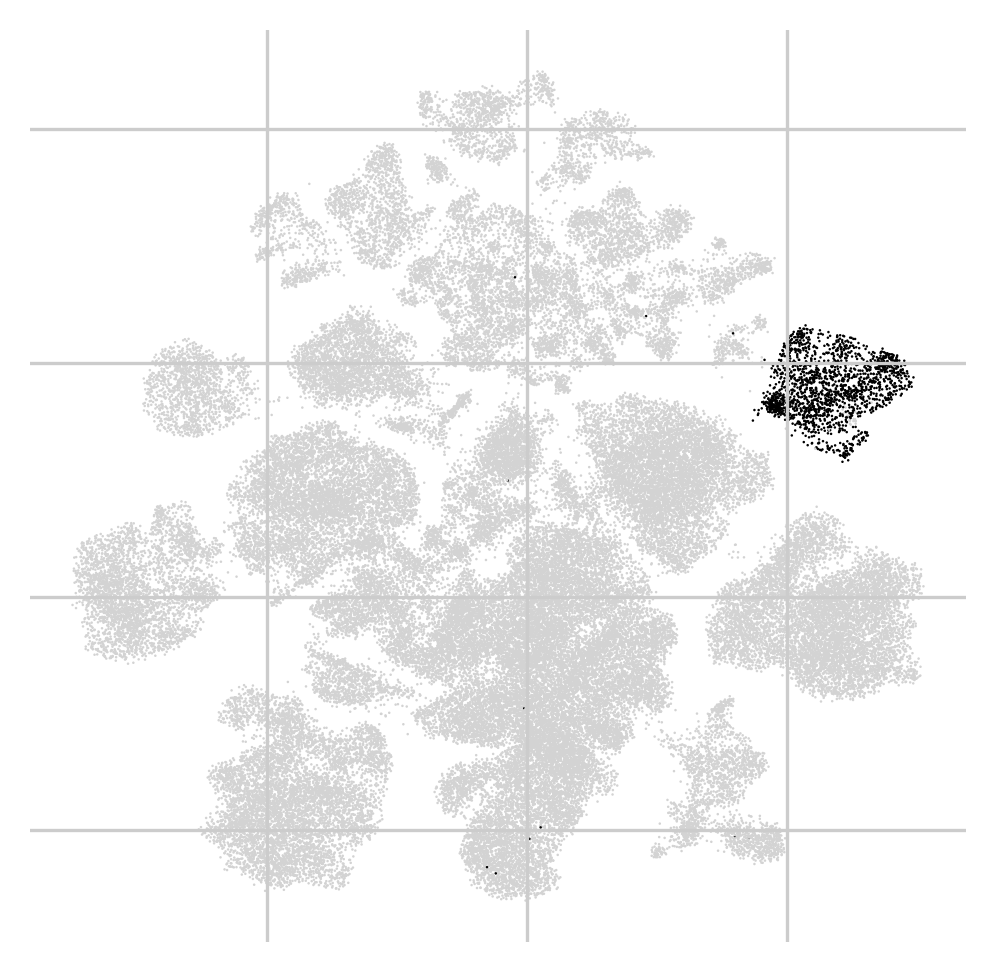

In [14]:
scv.pl.umap(adata_sgn,color="cell_type_final",)
scv.pl.umap(adata,color=["sel1"],palette=["lightgrey","k"],frameon=False,legend_loc="none",title="",save="./figures/SGN_analysis/human_sgn_highlight.pdf")

In [11]:
from matplotlib.patches import ConnectionPatch

<AxesSubplot: >

<AxesSubplot: xlabel='UMAP1', ylabel='UMAP2'>

Text(0.5, 0, '')

Text(0, 0.5, '')

meta NOT subset; don't know how to subset; dropped


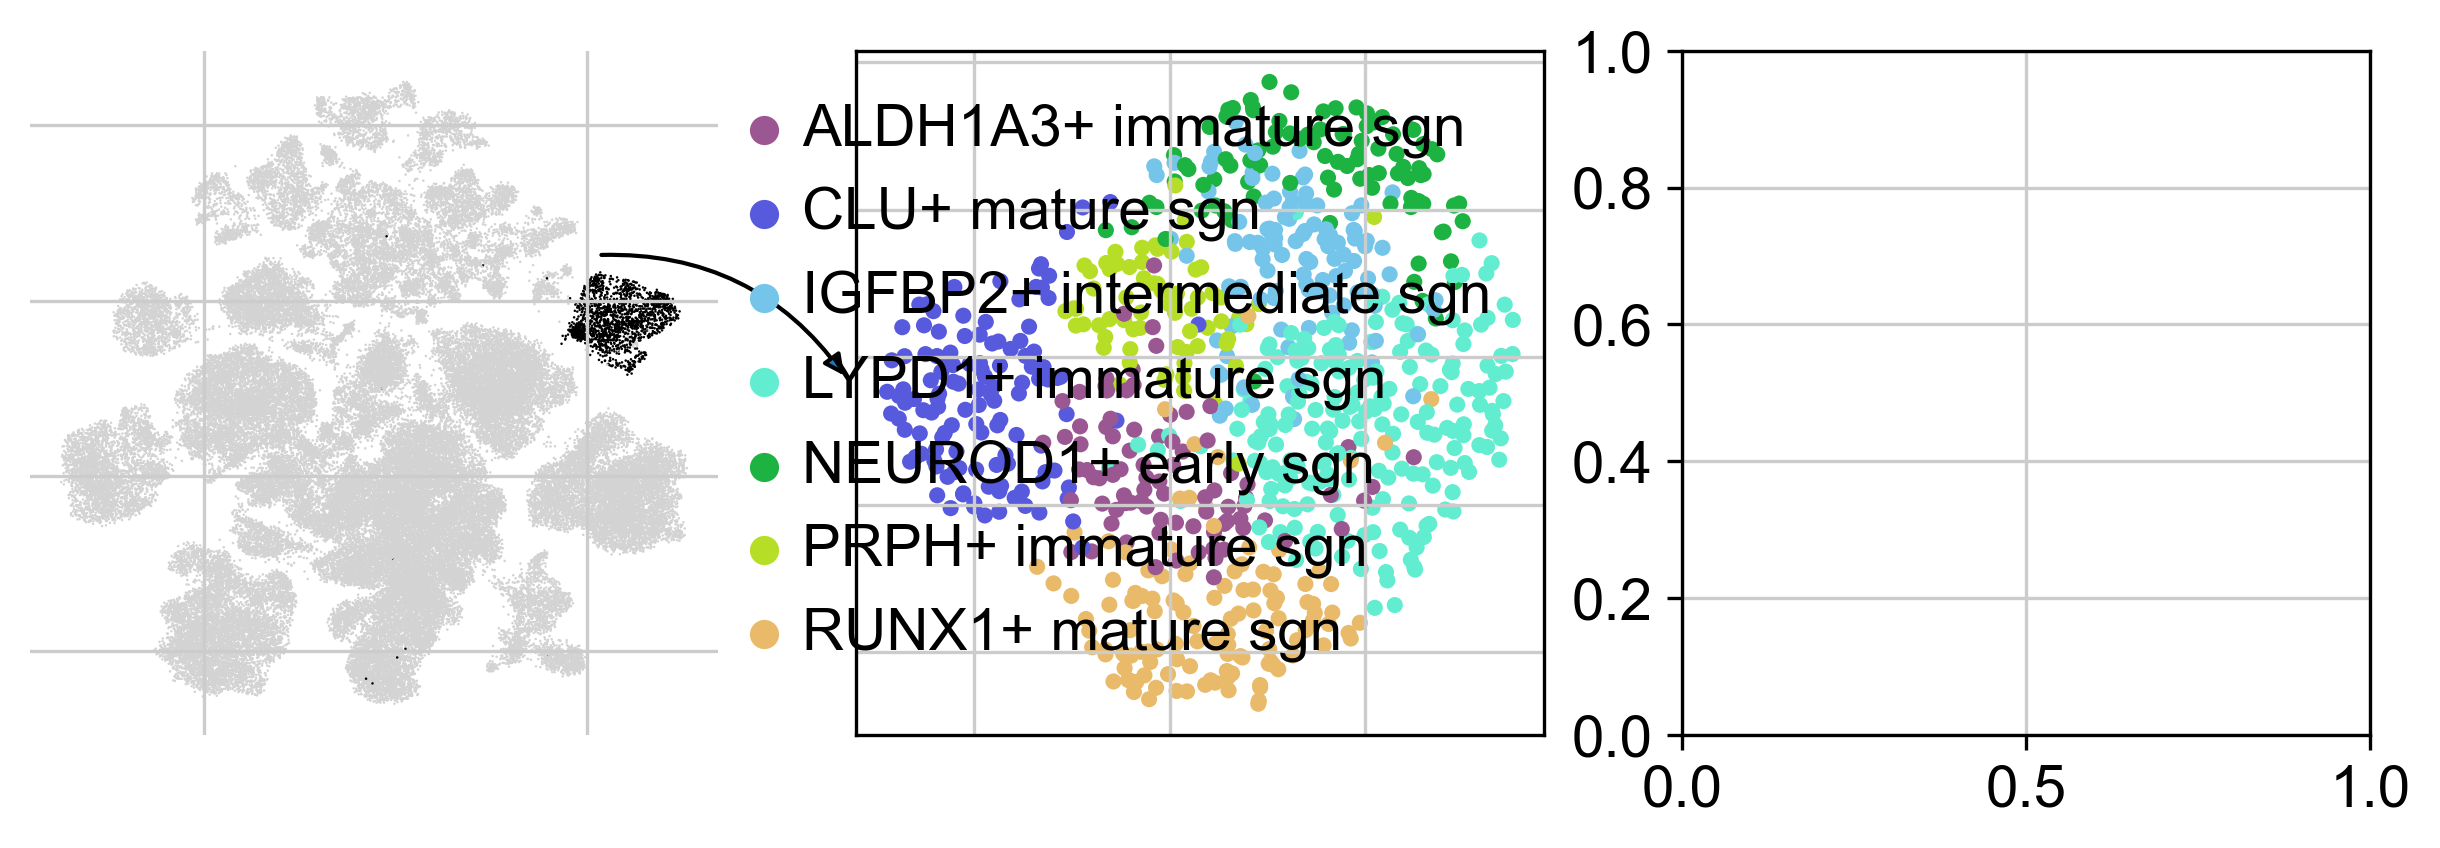

In [17]:
fig,axs=plt.subplots(1,3,figsize=(10,3))
scv.pl.umap(adata,color="sel1",ax=axs[0],show=False,
                  palette=["lightgrey","k"],frameon=False,legend_loc="none",title="")
scv.pl.umap(adata_sgn,color="cell_type_final",title="",frameon=True,ax=axs[1],legend_loc="none",
            show=False,palette=["#9b5792", "#575add", "#74c5e9",
             "#62edd0","#1db342", "#b7de27", 
             "#e8ba69",],size=60)
axs[1].set_xlabel("")
axs[1].set_ylabel("")
axs[1].legend(frameon=False,fontsize=14)

con1 = ConnectionPatch(xyA=(0.8, .7), coordsA="axes fraction", connectionstyle="arc3,rad=-0.3",arrowstyle="-|>",
                       xyB=(0, .5), coordsB="axes fraction", axesA=axs[0],axesB=axs[1],shrinkA=5,shrinkB=5)

axs[0].add_artist(con1)
plt.savefig("figures/SGN_analysis/human_sgn_highlight_v2.pdf",dpi=600)